# n-Armed Bandit

## Preliminaries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## Define a stochastic selector

In [20]:
def stochastic_chooser(probs: np.ndarray, n_picks:int, bin_bounds: str = 'ceiling_inclusive'):
    indices = np.arange(0, probs.shape[0])
    cum_probs_ceilings = np.cumsum(probs)
    cum_probs_floors = np.cumsum(np.hstack([0.0, probs[:-1]]).astype(float))
    seeds = np.random.rand(n_picks,)
    
    picks = np.nan*np.ones(n_picks,)
    for i, seed in enumerate(seeds):
        if bin_bounds == 'floor_inclusive':
            ceiling_check = np.logical_or((cum_probs_ceilings > seed), (1.0*np.ones_like(cum_probs_ceilings) <= seed))
            floor_check = (cum_probs_floors <= seed)
            select_mask = np.logical_and(ceiling_check, floor_check)
            pick = indices[select_mask]

        if bin_bounds == 'ceiling_inclusive':
            floor_check = np.logical_or((cum_probs_floors < seed), (0.0*np.ones_like(cum_probs_floors) >= seed))
            ceiling_check = (cum_probs_ceilings >= seed)
            select_mask = np.logical_and(ceiling_check, floor_check)
            pick = indices[select_mask]
            
        picks[i] = pick
        
    return picks.astype(int)

In [21]:
# test stochastic_chooser
probs = np.array([0.50, 0.15, 0.10, 0.25])
n_picks = 10
#action_indices = stochastic_chooser(probs, n_picks, bin_bounds='floor_inclusive')
action_indices = stochastic_chooser(probs, n_picks, bin_bounds='ceiling_inclusive')
action_indices

array([1, 0, 1, 0, 0, 0, 0, 2, 2, 1])

## Define Probabalistic Reward generator

In [42]:
def stochastic_reward_gen(mean_reward_value: float, standard_dev: float) -> float:
    
    seed = np.random.rand(1)
    # Inverse of the cumulative normal distribution at specified mean and standard_deviation
    reward = stats.norm.ppf(seed, loc=mean_reward_value, scale=standard_dev)
    
    return reward

In [62]:
# Test stochastic_reward_gen()
actual_reward_value = -3.0
standard_dev = 2.25
n_reps = 500
gen_rewards = np.array([
    stochastic_reward_gen(actual_reward_value, standard_dev) for rep in range(0, n_reps)
])
mean_gen_rewards = np.mean(gen_rewards)
stdev_gen_rewards = np.std(gen_rewards)

mean_gen_rewards, stdev_gen_rewards

(-2.9797555441070287, 2.2758312159896965)

## Define Action-value estimator

In [50]:
def action_value_estimator(reward: float, last_estimate: float, k_step: int) -> float:
    
    k_step = float(k_step)
    updated_estimate = last_estimate + (1. / k_step) * (reward - last_estimate)
    
    return updated_estimate

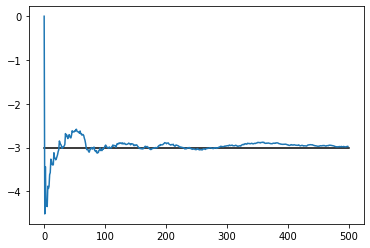

In [63]:
# test action_value_estimator
action_value_estimates = np.nan*np.ones_like(gen_rewards)
action_value_estimates[0] = 0.

for i, gen_reward in enumerate(gen_rewards[:-1]):
    k = i + 1
    action_value_estimates[k] = action_value_estimator(gen_reward, action_value_estimates[i], k)

plt.plot([0, action_value_estimates.shape[0]], [actual_reward_value, actual_reward_value], c="black")
plt.plot(action_value_estimates)

## Define Epsilon Greedy 

In [39]:
def epsilon_greedy_actor(action_value_estimates: np.ndarray, epsilon: float) -> int:
    
    n_actions = action_value_estimates.shape[0]
    action_indices = np.arange(0, n_actions)
    seed = np.random.rand(1)
    if seed < epsilon:
        action_index = np.random.choice(action_indices, size=1, replace=True)
    else:
        action_index = np.argmax(action_value_estimates)
        
    return action_index

In [41]:
# test epsilon_greedy_actor
action_value_estimates = np.array([1., 1., 1., 5., 1., 1.])
epsilon = 0.5
n_runs = 20
selections = np.nan*np.ones(n_runs)
for i in range(0, n_runs):
    selections[i] = epsilon_greedy_actor(action_value_estimates, epsilon)
    
selections.astype(int)

array([1, 0, 3, 5, 0, 3, 3, 1, 0, 3, 3, 3, 3, 4, 3, 2, 3, 2, 2, 2])

## Define Softmax_actor()

In [83]:
def softmax_actor(action_value_estimates: np.ndarray, tau: float) -> int:

    denom = np.sum(np.exp(action_value_estimates / tau))
    numer = np.exp(action_value_estimates / tau)
    
    probs = (1. / denom) * numer
    #print(f"value of probs: {probs}")
    action_index = stochastic_chooser(probs, n_picks=1, bin_bounds='ceiling_inclusive')
    
    return action_index

In [84]:
# test epsilon_greedy_actor
action_value_estimates = np.array([1., 1., 1., 5., 1., 1.])
tau = 2.0
n_runs = 20
selections = np.nan*np.ones(n_runs)
for i in range(0, n_runs):
    selections[i] = softmax_actor(action_value_estimates, tau)
    
selections.astype(int)

array([3, 3, 3, 3, 3, 3, 3, 2, 1, 0, 5, 3, 3, 3, 3, 3, 2, 2, 4, 3])